# IY029: catch22 + SVM — Pairwise Same/Different Task

Computes catch22 time-series features on each trajectory half and feeds
`[catch22(x1) | catch22(x2)]` (44 features per pair) to an RBF SVM.
Mirrors `IY029_mlp_pairwise.ipynb` and `IY029_transformer_pairwise.ipynb`.

## Feature extraction
- Split each concatenated pair at T//2 → full x1 and x2 (no crop)
- `pycatch22.catch22_all` on each half → 22 features per half
- Feature vector per pair: `[catch22(x1) | catch22(x2)]`, shape (N, 44)
- Parallelised across samples with `joblib` to reduce wall time

## Datasets
Same IY011 (2-fold) / IY014 (10-fold) static loaders as all other IY029 pairwise notebooks.
Chance = 50%.

## Saves
`IY029_catch22_svm_pairwise_results.json`

In [1]:
import sys
sys.path.insert(0, '../../src')

import json
import time
import numpy as np
import pycatch22
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from dataloaders import load_loader_from_disk

plt.rcParams.update({
    'font.family': 'sans-serif', 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'axes.titlesize': 14,
})

EXP_DIR    = Path('../..')
IY011_ROOT = EXP_DIR / 'experiments/EXP-25-IY011'
IY014_ROOT = EXP_DIR / 'experiments/EXP-26-IY014'

# Number of parallel workers for catch22 extraction (-1 = all CPU cores)
N_JOBS = -1

DATASET_CONFIGS = [
    {
        'name':        'Baseline',
        'iy011_train': IY011_ROOT / 'data'                / 'IY011_static_train.pt',
        'iy011_test':  IY011_ROOT / 'data'                / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data'                / 'IY014_static_train.pt',
        'iy014_test':  IY014_ROOT / 'data'                / 'IY014_static_test.pt',
    },
    {
        'name':        'Mu',
        'iy011_train': IY011_ROOT / 'data_mu_variation'   / 'IY011_static_train.pt',
        'iy011_test':  IY011_ROOT / 'data_mu_variation'   / 'IY011_static_test.pt',
        'iy014_train': IY011_ROOT / 'data_mu_variation'   / 'IY014_static_train.pt',
        'iy014_test':  IY011_ROOT / 'data_mu_variation'   / 'IY014_static_test.pt',
    },
    {
        'name':        'CV',
        'iy011_train': IY011_ROOT / 'data_cv_variation'   / 'IY011_static_train.pt',
        'iy011_test':  IY011_ROOT / 'data_cv_variation'   / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data_cv_variation'   / 'IY014_static_train.pt',
        'iy014_test':  IY014_ROOT / 'data_cv_variation'   / 'IY014_static_test.pt',
    },
    {
        'name':        'T_ac',
        'iy011_train': IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_train.pt',
        'iy011_test':  IY011_ROOT / 'data_t_ac_variation' / 'IY011_static_test.pt',
        'iy014_train': IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_train.pt',
        'iy014_test':  IY014_ROOT / 'data_t_ac_variation' / 'IY014_static_test.pt',
    },
]
DS_NAMES = [cfg['name'] for cfg in DATASET_CONFIGS]

## Helpers

In [2]:
def load_pair_data(train_pt: Path, test_pt: Path):
    """Load IY011/IY014 static loader → (X_train, X_test, y_train, y_test) numpy arrays."""
    def _extract(pt_path):
        loader = load_loader_from_disk(pt_path, batch_size=2048)
        Xs, ys = [], []
        for X, y in loader:
            Xs.append(X.numpy())
            ys.append(y.numpy().ravel())
        return np.concatenate(Xs), np.concatenate(ys).astype(int)

    X_train, y_train = _extract(train_pt)
    X_test,  y_test  = _extract(test_pt)
    return X_train, X_test, y_train, y_test


def _catch22_single(x: np.ndarray) -> list:
    """Compute 22 catch22 features for a single 1-D trajectory."""
    return pycatch22.catch22_all(x.tolist())['values']


def extract_catch22_pair(X_np: np.ndarray, n_jobs: int = N_JOBS) -> np.ndarray:
    """
    Compute [catch22(x1) | catch22(x2)] for each pair in X_np.

    X_np : (N, T, 1) — full concatenated pair.
    Returns (N, 44); NaNs from degenerate series replaced with 0.
    """
    half = X_np.shape[1] // 2
    x1_list = [X_np[i, :half, 0] for i in range(len(X_np))]
    x2_list = [X_np[i, half:, 0] for i in range(len(X_np))]

    f1 = Parallel(n_jobs=n_jobs)(delayed(_catch22_single)(x) for x in x1_list)
    f2 = Parallel(n_jobs=n_jobs)(delayed(_catch22_single)(x) for x in x2_list)

    feats = np.array([a + b for a, b in zip(f1, f2)], dtype=np.float32)
    return np.nan_to_num(feats, nan=0.0)


def run_svm(feats_tr: np.ndarray, feats_te: np.ndarray,
            y_tr: np.ndarray, y_te: np.ndarray) -> float:
    """Scale features, fit RBF SVM, return test accuracy."""
    scaler   = StandardScaler()
    feats_tr = scaler.fit_transform(feats_tr)
    feats_te = scaler.transform(feats_te)
    clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    clf.fit(feats_tr, y_tr)
    return clf.score(feats_te, y_te)

## Evaluation

In [3]:
results = {}   # {ds_name: {'iy011': acc, 'iy014': acc}}

for cfg in DATASET_CONFIGS:
    name = cfg['name']
    results[name] = {}
    print(f'\n=== {name} ===')

    for fold in ('iy011', 'iy014'):
        print(f'  {fold}: loading...', end=' ', flush=True)
        X_tr, X_te, y_tr, y_te = load_pair_data(
            cfg[f'{fold}_train'], cfg[f'{fold}_test']
        )
        print(f'train={X_tr.shape}, test={X_te.shape}  |  computing catch22...', flush=True)

        t0       = time.time()
        feats_tr = extract_catch22_pair(X_tr)
        feats_te = extract_catch22_pair(X_te)
        t1       = time.time()
        print(f'    features: {feats_tr.shape}  ({t1-t0:.1f}s)  |  fitting SVM...', flush=True)

        acc = run_svm(feats_tr, feats_te, y_tr, y_te)
        results[name][fold] = acc
        print(f'    test acc = {acc:.4f}')

print('\nDone.')


=== Baseline ===
  iy011: loading... 📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_train.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data/IY011_static_test.pt...
train=(3000, 3623, 1), test=(600, 3623, 1)  |  computing catch22...
    features: (3000, 44)  (8.8s)  |  fitting SVM...
    test acc = 0.8400
  iy014: loading... 📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_train.pt...
📂 Loading static data from ../../experiments/EXP-26-IY014/data/IY014_static_test.pt...
train=(3000, 3623, 1), test=(600, 3623, 1)  |  computing catch22...
    features: (3000, 44)  (8.4s)  |  fitting SVM...
    test acc = 0.9183

=== Mu ===
  iy011: loading... 📂 Loading static data from ../../experiments/EXP-25-IY011/data_mu_variation/IY011_static_train.pt...
📂 Loading static data from ../../experiments/EXP-25-IY011/data_mu_variation/IY011_static_test.pt...
train=(3000, 5021, 1), test=(600, 5021, 1)  |  computing catch22...
    fea

In [3]:
_save_path = Path('IY029_catch22_svm_pairwise_results.json')
if _save_path.exists():
    with open(_save_path) as _f:
        results = json.load(_f)
    print(f'Loaded existing {_save_path} (skipping overwrite)')
else:
    with open(_save_path, 'w') as _f:
        json.dump(
            {ds: {fold: float(results[ds][fold]) for fold in ('iy011', 'iy014')}
             for ds in DS_NAMES},
            _f, indent=2,
        )
    print(f'Saved {_save_path}')

Loaded existing IY029_catch22_svm_pairwise_results.json (skipping overwrite)


## Results

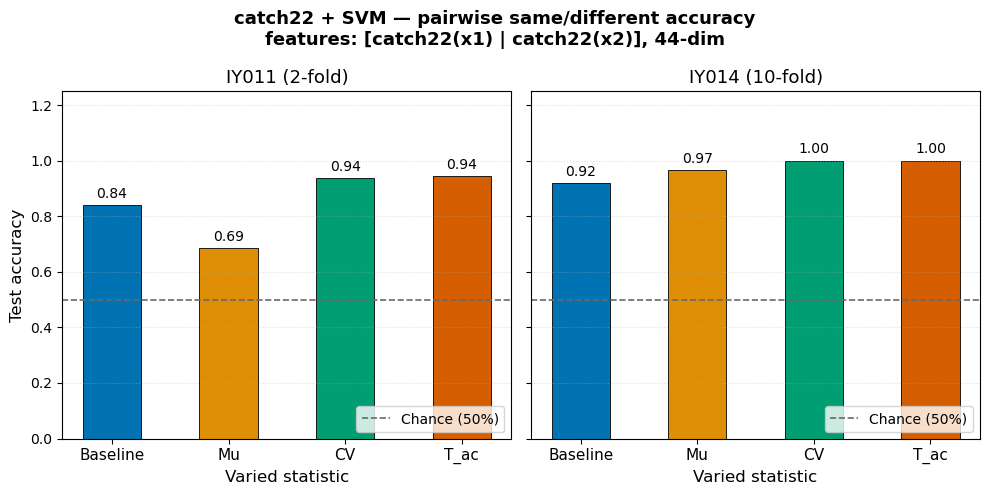

Saved IY029_catch22_svm_pairwise_acc.png


In [4]:
palette = sns.color_palette('colorblind')
colors  = [palette[i] for i in range(len(DS_NAMES))]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
x     = np.arange(len(DS_NAMES))
width = 0.5

for ax, fold_key, fold_title in [
    (axes[0], 'iy011', 'IY011 (2-fold)'),
    (axes[1], 'iy014', 'IY014 (10-fold)'),
]:
    accs = [results[n][fold_key] for n in DS_NAMES]
    bars = ax.bar(x, accs, width, color=colors, edgecolor='black', linewidth=0.6)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=10)
    ax.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1.2, label='Chance (50%)')
    ax.set_xticks(x)
    ax.set_xticklabels(DS_NAMES, fontsize=11)
    ax.set_xlabel('Varied statistic', fontsize=12)
    ax.set_ylim(0, 1.25)
    ax.set_title(fold_title, fontsize=13)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(axis='y', linestyle=':', alpha=0.4)

axes[0].set_ylabel('Test accuracy', fontsize=12)
fig.suptitle('catch22 + SVM — pairwise same/different accuracy\n'
             'features: [catch22(x1) | catch22(x2)], 44-dim',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig('IY029_catch22_svm_pairwise_acc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved IY029_catch22_svm_pairwise_acc.png')

In [5]:
import pandas as pd
rows = []
for n in DS_NAMES:
    rows.append({
        'Dataset':         n,
        '2-fold (IY011)':  results[n]['iy011'],
        '10-fold (IY014)': results[n]['iy014'],
        'Mean':            np.mean([results[n]['iy011'], results[n]['iy014']]),
    })
df = pd.DataFrame(rows).set_index('Dataset')
pd.set_option('display.float_format', '{:.3f}'.format)
print(df.to_string())

          2-fold (IY011)  10-fold (IY014)  Mean
Dataset                                        
Baseline           0.840            0.918 0.879
Mu                 0.687            0.967 0.827
CV                 0.938            1.000 0.969
T_ac               0.943            1.000 0.972
